# NIH ChestX-ray14 — Multi-Label Chest Pathology Classification
#
Multi-label classification of 14 chest pathologies from frontal chest X-rays.
ResNet-18, fine-tuned with per-class weighted loss, evaluated with bootstrap
confidence intervals, subgroup (gender/age) breakdowns, a view-position
hypothesis check, and Grad-CAM interpretability validated against NIH's
ground-truth bounding boxes (pointing-game metric).
#
Each image can have zero, one, or multiple conditions simultaneously — this
is why the model has 14 independent sigmoid outputs rather than one softmax.

In [1]:
import os
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
from sklearn.metrics import roc_auc_score

## 1. Configuration
#
`MINI_RUN = True` caps each split to 1000/200/200 images for a fast
end-to-end pipeline check before committing to a full run.
#
`torch.manual_seed` is set in addition to the `np.random.seed` used for the
train/val split below — without it, model initialisation and batch shuffling
are not reproducible even with the split fixed, which is why two earlier
runs of this notebook gave slightly different results (mean AUC 0.7904 vs
0.7892) from what looked like identical code.

In [2]:
MINI_RUN = False   # True = quick pipeline test | False = full run

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False  # trades some speed for determinism

if os.path.exists("/kaggle/input"):
    BASE = Path("/kaggle/input/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized")
else:
    # Set NIH_DATA_DIR or edit this path if running outside Kaggle.
    BASE = Path(os.environ.get("NIH_DATA_DIR", "./data/nih-chest-xray14"))

IMG_DIR    = BASE / "images-224" / "images-224"
CSV_PATH   = BASE / "Data_Entry_2017.csv"
TRAIN_LIST = BASE / "train_val_list_NIH.txt"
TEST_LIST  = BASE / "test_list_NIH.txt"

IMG_SIZE = 224  # dataset is pre-resized; set True below if using the official 1024x1024 release
RESIZE_NEEDED = False

BATCH_SIZE     = 32
MAX_EPOCHS     = 20
EARLY_PATIENCE = 4
LR             = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Mode:   {'MINI' if MINI_RUN else 'FULL'}")
print(f"\nCSV exists:      {CSV_PATH.exists()}")
print(f"Train list:      {TRAIN_LIST.exists()}")
print(f"Test list:       {TEST_LIST.exists()}")
print(f"PNG files found: {len(list(IMG_DIR.glob('*.png'))) if IMG_DIR.exists() else 'IMG_DIR missing'}")

Device: cuda
Mode:   FULL

CSV exists:      True
Train list:      True
Test list:       True
PNG files found: 112120


## 2. Load and Explore the Dataset
#
`Data_Entry_2017.csv` has one row per image with a pipe-separated
`Finding Labels` column (e.g. `"Atelectasis|Effusion"`). Multiple images
exist per patient (repeat visits), which is why the split below is done by
patient, not by image.

In [3]:
df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape}")
print(df[["Image Index", "Finding Labels", "Patient ID"]].head(8))

Shape: (112120, 12)
        Image Index          Finding Labels  Patient ID
0  00000001_000.png            Cardiomegaly           1
1  00000001_001.png  Cardiomegaly|Emphysema           1
2  00000001_002.png   Cardiomegaly|Effusion           1
3  00000002_000.png              No Finding           2
4  00000003_000.png                  Hernia           3
5  00000003_001.png                  Hernia           3
6  00000003_002.png                  Hernia           3
7  00000003_003.png     Hernia|Infiltration           3


## 3. Parse Multi-Label Column Into 14 Binary Columns
#
Substring matching (`label in x`) is safe here specifically because none of
the 14 label strings is a substring of another — checked once, not assumed.

In [4]:
LABELS = [
    "Atelectasis", "Consolidation", "Infiltration", "Pneumothorax",
    "Edema", "Emphysema", "Fibrosis", "Effusion", "Pneumonia",
    "Pleural_Thickening", "Cardiomegaly", "Nodule", "Mass", "Hernia"
]
assert not any(a in b for a in LABELS for b in LABELS if a != b), \
    "A label name is a substring of another — substring matching below would misfire."

for label in LABELS:
    df[label] = df["Finding Labels"].apply(lambda x: 1 if label in x else 0)

print(f"Total images:              {len(df):,}")
print(f"Images with No Finding:    {(df['Finding Labels'] == 'No Finding').sum():,}")
print(f"Images with >=1 condition: {(df['Finding Labels'] != 'No Finding').sum():,}")

Total images:              112,120
Images with No Finding:    60,412
Images with >=1 condition: 51,708


## 4. Class Distribution

Positive counts and rates per class:
  Infiltration           19,870  (17.7%)
  Effusion               13,307  (11.9%)
  Atelectasis            11,535  (10.3%)
  Nodule                  6,323  (5.6%)
  Mass                    5,746  (5.1%)
  Pneumothorax            5,298  (4.7%)
  Consolidation           4,667  (4.2%)
  Pleural_Thickening      3,385  (3.0%)
  Cardiomegaly            2,772  (2.5%)
  Emphysema               2,516  (2.2%)
  Edema                   2,303  (2.0%)
  Fibrosis                1,686  (1.5%)
  Pneumonia               1,353  (1.2%)
  Hernia                    227  (0.2%)


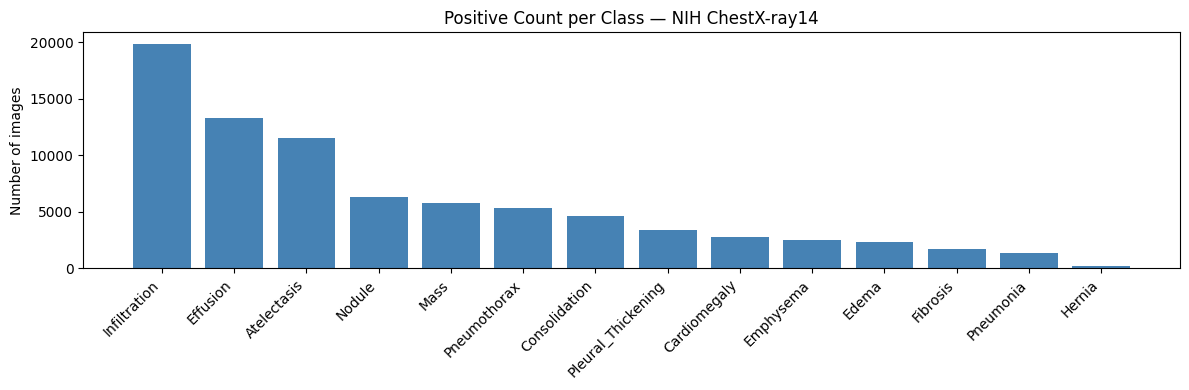

In [5]:
label_counts = df[LABELS].sum().sort_values(ascending=False)
label_pct    = (label_counts / len(df) * 100).round(2)

print("Positive counts and rates per class:")
for label in label_counts.index:
    print(f"  {label:<22} {label_counts[label]:6,}  ({label_pct[label]:.1f}%)")

plt.figure(figsize=(12, 4))
plt.bar(label_counts.index, label_counts.values, color="steelblue")
plt.title("Positive Count per Class — NIH ChestX-ray14")
plt.ylabel("Number of images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. Label Co-occurrence

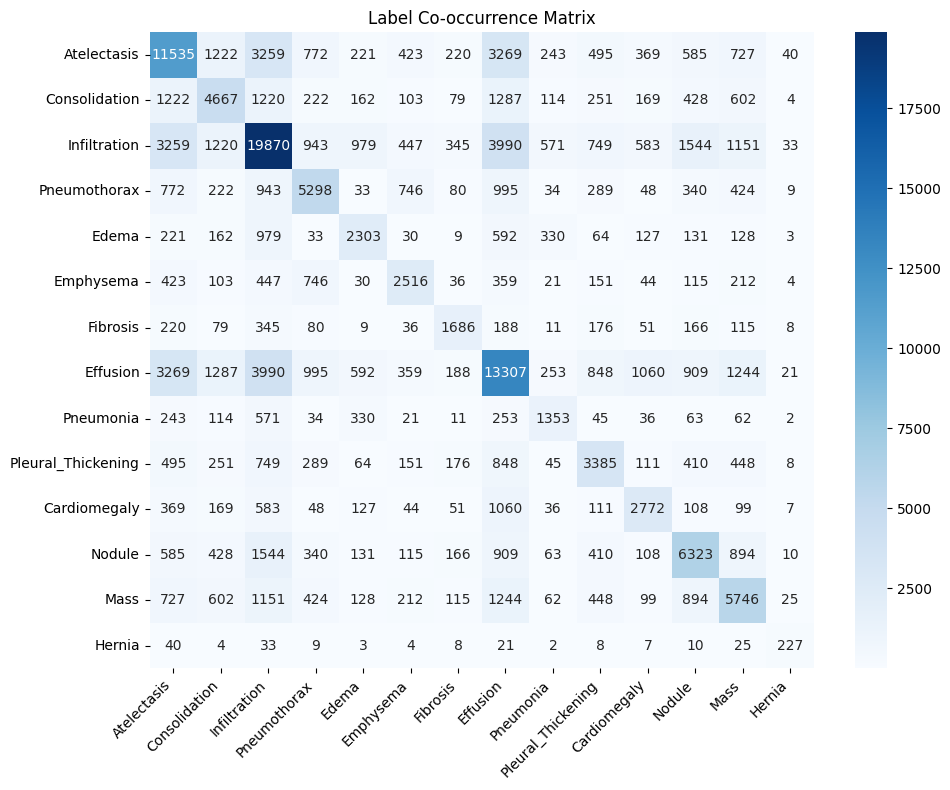

In [6]:
co_matrix = df[LABELS].T.dot(df[LABELS])

plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABELS, yticklabels=LABELS)
plt.title("Label Co-occurrence Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Patient-Disjoint Train / Val / Test Split
#
The dataset provides official train and test lists split by patient. We use
those directly and further split train_val 90/10 by patient ID. Splitting by
patient (not image) prevents the same patient appearing in both train and
test through repeat visits.

In [7]:
train_val_files = set(open(TRAIN_LIST).read().splitlines())
test_files      = set(open(TEST_LIST).read().splitlines())

df_trainval = df[df["Image Index"].isin(train_val_files)].copy()
df_test     = df[df["Image Index"].isin(test_files)].copy()

trainval_patients = df_trainval["Patient ID"].unique()
np.random.shuffle(trainval_patients)

n_val        = int(len(trainval_patients) * 0.10)
val_patients = set(trainval_patients[:n_val])

df_train = df_trainval[~df_trainval["Patient ID"].isin(val_patients)]
df_val   = df_trainval[df_trainval["Patient ID"].isin(val_patients)]

print(f"Train: {len(df_train):,} images ({df_train['Patient ID'].nunique():,} patients)")
print(f"Val:   {len(df_val):,} images ({df_val['Patient ID'].nunique():,} patients)")
print(f"Test:  {len(df_test):,} images ({df_test['Patient ID'].nunique():,} patients)")

assert len(set(df_train["Patient ID"]) & set(df_val["Patient ID"]))  == 0
assert len(set(df_train["Patient ID"]) & set(df_test["Patient ID"])) == 0
assert len(set(df_val["Patient ID"])   & set(df_test["Patient ID"])) == 0
print("\nPatient overlap check: PASSED")

Train: 77,994 images (25,208 patients)
Val:   8,530 images (2,800 patients)
Test:  25,596 images (2,797 patients)

Patient overlap check: PASSED


## 7. MINI_RUN Subsetting

In [8]:
if MINI_RUN:
    df_train = df_train.sample(n=min(1000, len(df_train)), random_state=SEED)
    df_val   = df_val.sample(n=min(200,  len(df_val)),   random_state=SEED)
    df_test  = df_test.sample(n=min(200,  len(df_test)),  random_state=SEED)
    print(f"MINI — Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")
else:
    print(f"FULL — Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

print("\nPositive count per class in train:")
for label in LABELS:
    print(f"  {label:<22} {df_train[label].sum():4d}")

FULL — Train: 77,994 | Val: 8,530 | Test: 25,596

Positive count per class in train:
  Atelectasis            7405
  Consolidation          2584
  Infiltration           12480
  Pneumothorax           2394
  Edema                  1253
  Emphysema              1317
  Fibrosis               1111
  Effusion               7852
  Pneumonia               783
  Pleural_Thickening     1997
  Cardiomegaly           1549
  Nodule                 4247
  Mass                   3646
  Hernia                  122


## 8. Dataset Class

In [9]:
class ChestXrayDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(self.img_dir / row["Image Index"]).convert("RGB")
        label = torch.tensor(row[LABELS].values.astype(np.float32))
        if self.transform:
            img = self.transform(img)
        return img, label

## 9. Transforms and DataLoaders
#
`RandomHorizontalFlip` only — no vertical flip (the heart must stay at the
top) and no rotation beyond what's clinically plausible for an upright film.
ImageNet normalisation is required because ResNet's pretrained weights
expect pixel values in that range.

In [10]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

_resize = [transforms.Resize(IMG_SIZE)] if RESIZE_NEEDED else []

train_transform = transforms.Compose(_resize + [
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

val_test_transform = transforms.Compose(_resize + [
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_ds = ChestXrayDataset(df_train, IMG_DIR, transform=train_transform)
val_ds   = ChestXrayDataset(df_val,   IMG_DIR, transform=val_test_transform)
test_ds  = ChestXrayDataset(df_test,  IMG_DIR, transform=val_test_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

imgs_b, labels_b = next(iter(train_loader))
print(f"Batch image shape: {imgs_b.shape}")
print(f"Batch label shape: {labels_b.shape}")

Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32, 14])


## 10. Per-Class pos_weight
#
Positive rates range from ~18% to ~0.2% across classes, so a single global
weight would be wrong — each of the 14 loss terms gets its own
`neg_count / pos_count` weight.

In [11]:
pos_counts = df_train[LABELS].sum().values.astype(np.float32)
neg_counts = len(df_train) - pos_counts
pos_weight = torch.tensor(neg_counts / np.clip(pos_counts, 1, None),
                          dtype=torch.float32).to(DEVICE)

print("Per-class pos_weight:")
for i, label in enumerate(LABELS):
    print(f"  {label:<22} pos={int(pos_counts[i]):5d}  weight={pos_weight[i].item():.1f}")

Per-class pos_weight:
  Atelectasis            pos= 7405  weight=9.5
  Consolidation          pos= 2584  weight=29.2
  Infiltration           pos=12480  weight=5.2
  Pneumothorax           pos= 2394  weight=31.6
  Edema                  pos= 1253  weight=61.2
  Emphysema              pos= 1317  weight=58.2
  Fibrosis               pos= 1111  weight=69.2
  Effusion               pos= 7852  weight=8.9
  Pneumonia              pos=  783  weight=98.6
  Pleural_Thickening     pos= 1997  weight=38.1
  Cardiomegaly           pos= 1549  weight=49.4
  Nodule                 pos= 4247  weight=17.4
  Mass                   pos= 3646  weight=20.4
  Hernia                 pos=  122  weight=638.3


## 11. Model
#
ResNet-18 pretrained on ImageNet, final layer replaced with 14 outputs.
14 independent sigmoids, not softmax — softmax assumes mutually exclusive
classes (probabilities sum to 1), which is wrong here since a patient can
have Effusion AND Consolidation simultaneously.
#
A ResNet-50 run (`nn.Linear(2048, 14)` with `models.resnet50(...)`) is a
natural next step but has not been trained — this script only reports what
was actually run.

In [12]:
model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(512, 14)
model = model.to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode="max", patience=2, factor=0.5)

print(f"Output layer: {model.fc}")
print(f"Parameters:   {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 223MB/s]

Output layer: Linear(in_features=512, out_features=14, bias=True)
Parameters:   11,183,694


## 12. Training
#
AUC is computed per class then averaged; classes with no positives in a
given batch/split are skipped (`ValueError` from `roc_auc_score`, caught
specifically — not a bare `except`, so a real bug can't hide here).

In [13]:
CHECKPOINT_PATH = "/kaggle/working/best_model.pth" if os.path.exists("/kaggle/working") else "./best_model.pth"

best_auc, patience_count = 0.0, 0
history = {"train_loss": [], "val_auc": []}

for epoch in range(1, MAX_EPOCHS + 1):

    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs   = imgs.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(imgs)
    train_loss = running_loss / len(train_ds)

    model.eval()
    val_probs, val_targets = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            probs = torch.sigmoid(model(imgs.to(DEVICE))).cpu().numpy()
            val_probs.extend(probs)
            val_targets.extend(labels.numpy())

    val_probs   = np.array(val_probs)
    val_targets = np.array(val_targets)

    aucs = []
    for i in range(14):
        if val_targets[:, i].sum() > 0:
            try:
                aucs.append(roc_auc_score(val_targets[:, i], val_probs[:, i]))
            except ValueError as e:
                print(f"  Skipping {LABELS[i]} (val): {e}")
    val_auc = np.mean(aucs)
    scheduler.step(val_auc)

    history["train_loss"].append(train_loss)
    history["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val AUC: {val_auc:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    if val_auc > best_auc:
        best_auc, patience_count = val_auc, 0
        torch.save(model.state_dict(), CHECKPOINT_PATH)
    else:
        patience_count += 1
        if patience_count >= EARLY_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print(f"\nBest Val Mean AUC: {best_auc:.4f}")

Epoch 01/20 | Train Loss: 1.1260 | Val AUC: 0.7886 | LR: 1.00e-04
Epoch 02/20 | Train Loss: 1.0361 | Val AUC: 0.8044 | LR: 1.00e-04
Epoch 03/20 | Train Loss: 0.9807 | Val AUC: 0.7874 | LR: 1.00e-04
Epoch 04/20 | Train Loss: 0.9468 | Val AUC: 0.8083 | LR: 1.00e-04
Epoch 05/20 | Train Loss: 0.9014 | Val AUC: 0.8117 | LR: 1.00e-04
Epoch 06/20 | Train Loss: 0.8578 | Val AUC: 0.8135 | LR: 1.00e-04
Epoch 07/20 | Train Loss: 0.8107 | Val AUC: 0.8138 | LR: 1.00e-04
Epoch 08/20 | Train Loss: 0.7552 | Val AUC: 0.7919 | LR: 1.00e-04
Epoch 09/20 | Train Loss: 0.7238 | Val AUC: 0.8128 | LR: 1.00e-04
Epoch 10/20 | Train Loss: 0.6717 | Val AUC: 0.8055 | LR: 5.00e-05
Epoch 11/20 | Train Loss: 0.5585 | Val AUC: 0.8046 | LR: 5.00e-05

Early stopping at epoch 11.

Best Val Mean AUC: 0.8138


## 13. Training Curves

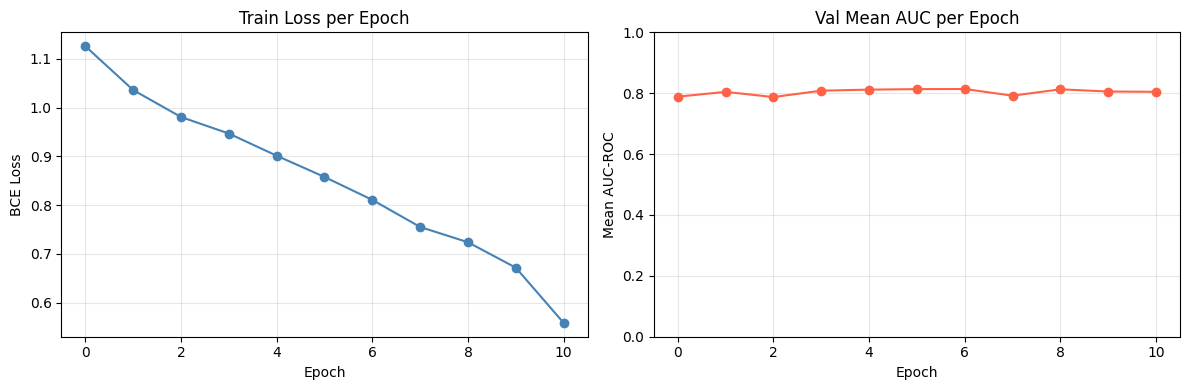

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], marker="o", color="steelblue")
ax1.set_title("Train Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(history["val_auc"], marker="o", color="tomato")
ax2.set_title("Val Mean AUC per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Mean AUC-ROC")
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Test Evaluation — AUC Per Class
#
Evaluated on the official patient-disjoint test set.

In [15]:
model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()

test_probs, test_targets = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        probs = torch.sigmoid(model(imgs.to(DEVICE))).cpu().numpy()
        test_probs.extend(probs)
        test_targets.extend(labels.numpy())

test_probs   = np.array(test_probs)
test_targets = np.array(test_targets)

print(f"{'Class':<22} {'AUC':>6}")
print("-" * 30)
class_aucs = []
for i, label in enumerate(LABELS):
    if test_targets[:, i].sum() > 0:
        try:
            auc = roc_auc_score(test_targets[:, i], test_probs[:, i])
            class_aucs.append(auc)
            print(f"{label:<22} {auc:.4f}")
        except ValueError as e:
            print(f"{label:<22}   N/A ({e})")
    else:
        print(f"{label:<22}   N/A (no positives in test)")
print("-" * 30)
print(f"{'Mean AUC':<22} {np.mean(class_aucs):.4f}")

Class                     AUC
------------------------------
Atelectasis            0.7486
Consolidation          0.7246
Infiltration           0.6883
Pneumothorax           0.8452
Edema                  0.8303
Emphysema              0.8988
Fibrosis               0.7798
Effusion               0.8150
Pneumonia              0.6982
Pleural_Thickening     0.7536
Cardiomegaly           0.8781
Nodule                 0.7163
Mass                   0.7814
Hernia                 0.9029
------------------------------
Mean AUC               0.7901


## 15. Grad-CAM — Qualitative Check (n=1 per class)
#
Generates a heatmap for the single highest-confidence true positive per
class. **This is a qualitative, anecdotal check, not a measurement** — a
visual pattern here is a hypothesis about model behaviour, not a validated
finding. Section 19 below turns this into an actual per-class number
against NIH's ground-truth bounding boxes.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 88.8 MB/s eta 0:00:00


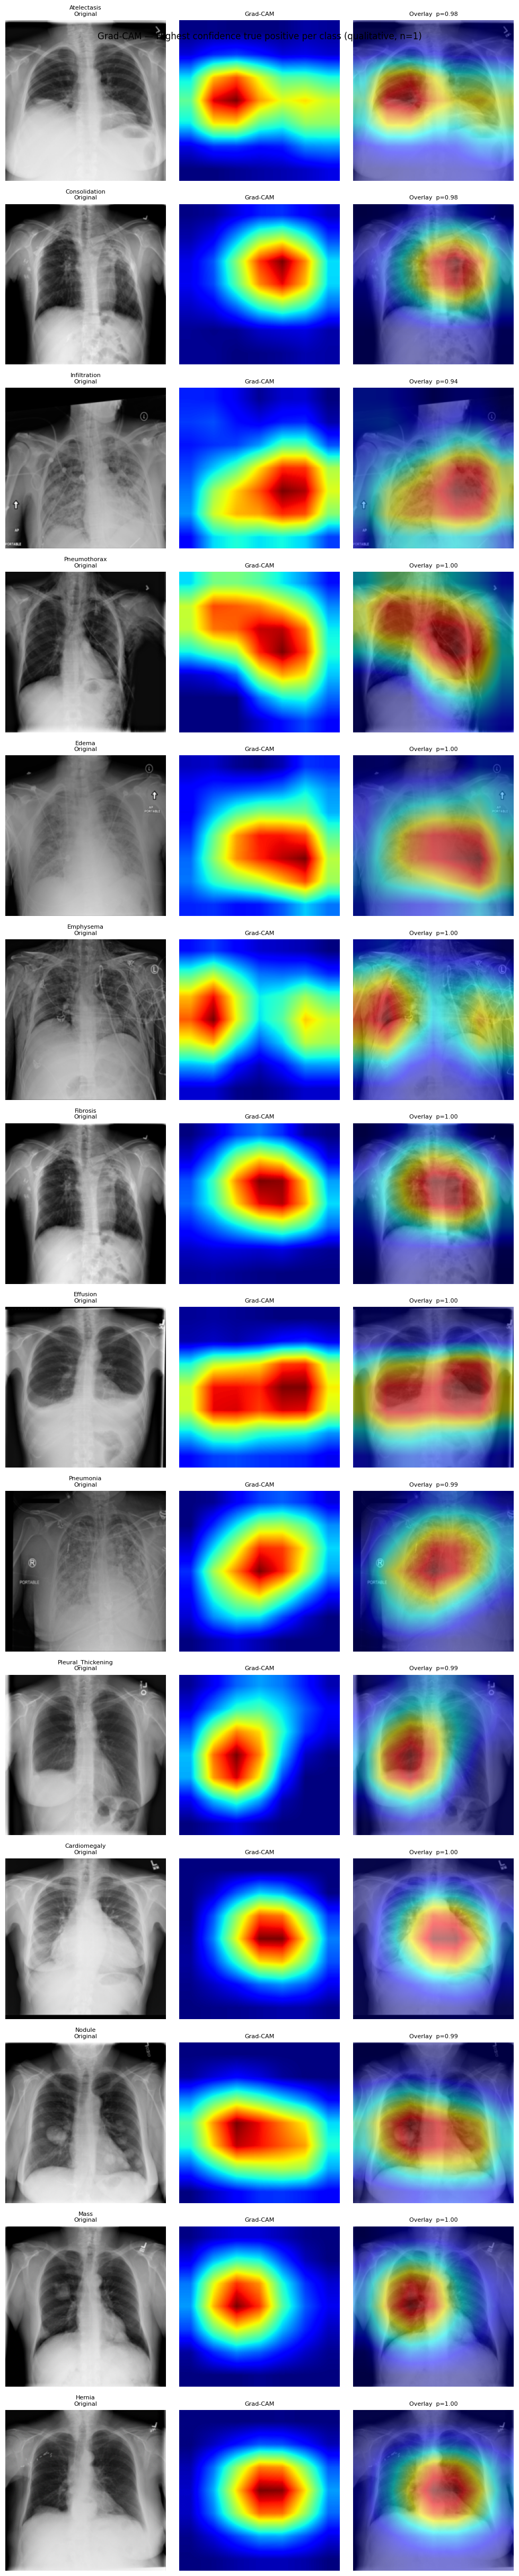

In [16]:
subprocess.run(["pip", "install", "grad-cam", "-q"])

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

model = models.resnet18(weights=None)
model.fc = nn.Linear(512, 14)
model.load_state_dict(torch.load(CHECKPOINT_PATH))
model = model.to(DEVICE)
model.eval()

cam = GradCAM(model=model, target_layers=[model.layer4[-1]])

n_classes_with_pos = sum(1 for i in range(14) if test_targets[:, i].sum() > 0)
fig, axes = plt.subplots(n_classes_with_pos, 3, figsize=(10, n_classes_with_pos * 3.5))
row = 0

for class_idx, label in enumerate(LABELS):
    pos_mask = test_targets[:, class_idx] == 1
    if pos_mask.sum() == 0:
        continue

    class_probs = test_probs[pos_mask, class_idx]
    best_local  = np.argmax(class_probs)
    best_global = np.where(pos_mask)[0][best_local]
    prob        = class_probs[best_local]

    row_data   = test_ds.df.iloc[best_global]
    img_pil    = Image.open(IMG_DIR / row_data["Image Index"]).convert("RGB")
    img_np     = np.array(img_pil).astype(np.float32) / 255.0
    img_tensor = val_test_transform(img_pil).unsqueeze(0).to(DEVICE)

    heatmap = cam(input_tensor=img_tensor, targets=[ClassifierOutputTarget(class_idx)])[0]
    overlay = show_cam_on_image(img_np, heatmap, use_rgb=True)

    axes[row, 0].imshow(img_pil, cmap="gray")
    axes[row, 0].set_title(f"{label}\nOriginal", fontsize=8)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(heatmap, cmap="jet", vmin=0, vmax=1)
    axes[row, 1].set_title("Grad-CAM", fontsize=8)
    axes[row, 1].axis("off")

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(f"Overlay  p={prob:.2f}", fontsize=8)
    axes[row, 2].axis("off")

    row += 1

plt.suptitle("Grad-CAM — Highest confidence true positive per class (qualitative, n=1)", fontsize=12)
plt.tight_layout()
plt.show()

## 16. Bootstrap 95% Confidence Intervals on Test AUC
#
A point-estimate AUC on a class with 86 positives (Hernia) isn't precise
enough to report on its own. Resample the test set with replacement 1000
times, recompute AUC each time, and take the 2.5th/97.5th percentiles as a
95% CI. This is the standard nonparametric approach and requires no
distributional assumptions — the trade-off is that it can't be computed
analytically in one line the way a normal-theory CI could.

In [17]:
def bootstrap_auc_ci(y_true, y_score, n_boot=1000, ci=0.95, seed=SEED):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    boot_aucs = []
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        y_t, y_s = y_true[idx], y_score[idx]
        if y_t.sum() == 0 or y_t.sum() == n:
            continue
        boot_aucs.append(roc_auc_score(y_t, y_s))
    boot_aucs = np.array(boot_aucs)
    lo = np.percentile(boot_aucs, (1 - ci) / 2 * 100)
    hi = np.percentile(boot_aucs, (1 + ci) / 2 * 100)
    return lo, hi

auc_ci_rows = []
for i, label in enumerate(LABELS):
    y_true, y_score = test_targets[:, i], test_probs[:, i]
    n_pos = int(y_true.sum())
    if n_pos == 0:
        continue
    point_auc = roc_auc_score(y_true, y_score)
    lo, hi = bootstrap_auc_ci(y_true, y_score)
    auc_ci_rows.append({
        "Class": label, "AUC": round(point_auc, 4),
        "CI_low": round(lo, 4), "CI_high": round(hi, 4),
        "CI_width": round(hi - lo, 4), "Test_positives": n_pos,
    })

auc_ci_df = pd.DataFrame(auc_ci_rows).sort_values("AUC", ascending=False)
print(auc_ci_df.to_string(index=False))
auc_ci_df.to_csv("test_auc_bootstrap_ci.csv", index=False)

             Class    AUC  CI_low  CI_high  CI_width  Test_positives
            Hernia 0.9029  0.8597   0.9408    0.0812              86
         Emphysema 0.8988  0.8897   0.9086    0.0189            1093
      Cardiomegaly 0.8781  0.8684   0.8872    0.0188            1065
      Pneumothorax 0.8452  0.8382   0.8527    0.0145            2661
             Edema 0.8303  0.8195   0.8421    0.0226             925
          Effusion 0.8150  0.8085   0.8216    0.0131            4648
              Mass 0.7814  0.7691   0.7925    0.0234            1712
          Fibrosis 0.7798  0.7588   0.8028    0.0441             435
Pleural_Thickening 0.7536  0.7397   0.7671    0.0274            1143
       Atelectasis 0.7486  0.7400   0.7580    0.0180            3255
     Consolidation 0.7246  0.7144   0.7353    0.0209            1815
            Nodule 0.7163  0.7029   0.7296    0.0267            1615
         Pneumonia 0.6982  0.6747   0.7211    0.0464             477
      Infiltration 0.6883  0.6808 

## 17. Subgroup AUC by Patient Gender and Age Band
#
`Patient Age` in the raw CSV can include non-numeric characters — extract
the digits with a regex rather than assuming it's already a clean int, and
**print a warning if parsing fails** so a silent all-NaN column (as
happened previously) can't go unnoticed again.
#
Age bands simplified to three (`<40` / `40-60` / `60+`) rather than five —
fewer near-empty bins, easier to reason about and defend.

In [18]:
def parse_patient_age(raw_series):
    digits = raw_series.astype(str).str.extract(r"(\d+)", expand=False)
    parsed = pd.to_numeric(digits, errors="coerce")
    n_failed = int(parsed.isna().sum())
    if n_failed > 0:
        print(f"WARNING: {n_failed} / {len(parsed)} Patient Age values could not be parsed.")
        print("Sample of raw values that failed:")
        print(raw_series[parsed.isna()].head(5).tolist())
    return parsed

test_meta = test_ds.df.copy().reset_index(drop=True)
test_meta["Patient Age"] = parse_patient_age(test_meta["Patient Age"])

n_implausible = int((test_meta["Patient Age"] > 100).sum())
test_meta.loc[test_meta["Patient Age"] > 100, "Patient Age"] = np.nan
print(f"Excluded {n_implausible} rows with implausible age (>100)")
print(f"Age parsed successfully for {test_meta['Patient Age'].notna().sum()} / {len(test_meta)} rows")

age_bins   = [0, 40, 60, 120]
age_labels = ["<40", "40-60", "60+"]
test_meta["Age Band"] = pd.cut(test_meta["Patient Age"], bins=age_bins,
                                labels=age_labels, right=False)

def stratified_auc(mask, class_idx):
    y_t, y_s = test_targets[mask, class_idx], test_probs[mask, class_idx]
    n_pos = int(y_t.sum())
    if n_pos == 0 or n_pos == len(y_t):
        return np.nan, n_pos
    return roc_auc_score(y_t, y_s), n_pos

gender_rows = []
for i, label in enumerate(LABELS):
    for gender in ["M", "F"]:
        mask = (test_meta["Patient Gender"] == gender).values
        auc, n_pos = stratified_auc(mask, i)
        gender_rows.append({"Class": label, "Gender": gender,
                             "AUC": auc, "n_pos": n_pos, "n_total": int(mask.sum())})
gender_df = pd.DataFrame(gender_rows)
gender_pivot = gender_df.pivot(index="Class", columns="Gender", values="AUC")
gender_pivot["Gap (M-F)"] = gender_pivot["M"] - gender_pivot["F"]
print("\n--- AUC by Gender ---")
print(gender_pivot.sort_values("Gap (M-F)", key=abs, ascending=False).round(4))
gender_df.to_csv("subgroup_auc_gender.csv", index=False)

age_rows = []
for i, label in enumerate(LABELS):
    for band in age_labels:
        mask = (test_meta["Age Band"] == band).values
        auc, n_pos = stratified_auc(mask, i)
        age_rows.append({"Class": label, "Age Band": band,
                          "AUC": auc, "n_pos": n_pos, "n_total": int(mask.sum())})
age_df = pd.DataFrame(age_rows)
age_pivot = age_df.pivot(index="Class", columns="Age Band", values="AUC")
print("\n--- AUC by Age Band ---")
print(age_pivot.round(4))
age_df.to_csv("subgroup_auc_age.csv", index=False)

Excluded 4 rows with implausible age (>100)
Age parsed successfully for 25592 / 25596 rows

--- AUC by Gender ---
Gender                   F       M  Gap (M-F)
Class                                        
Hernia              0.9279  0.8762    -0.0517
Fibrosis            0.7516  0.8013     0.0497
Nodule              0.7435  0.6962    -0.0473
Effusion            0.7994  0.8255     0.0261
Pleural_Thickening  0.7665  0.7438    -0.0227
Atelectasis         0.7361  0.7579     0.0218
Pneumonia           0.6872  0.7054     0.0182
Mass                0.7726  0.7877     0.0151
Pneumothorax        0.8509  0.8403    -0.0106
Cardiomegaly        0.8815  0.8746    -0.0069
Consolidation       0.7283  0.7217    -0.0066
Infiltration        0.6852  0.6907     0.0054
Emphysema           0.9010  0.8972    -0.0038
Edema               0.8309  0.8295    -0.0014

--- AUC by Age Band ---
Age Band             40-60     60+     <40
Class                                     
Atelectasis         0.7382  0.7307  0.7

## 18. View-Position (AP/PA) Stratified AUC
#
Directly tests the hypothesis that Pneumothorax/Effusion/Atelectasis AUC is
inflated by film-acquisition type (portable AP vs standard PA) acting as a
confounder, rather than the model isolating the pathology itself.

In [19]:
view_rows = []
for i, label in enumerate(LABELS):
    for view in ["AP", "PA"]:
        mask = (test_meta["View Position"] == view).values
        auc, n_pos = stratified_auc(mask, i)
        view_rows.append({"Class": label, "View": view,
                           "AUC": auc, "n_pos": n_pos, "n_total": int(mask.sum())})
view_df = pd.DataFrame(view_rows)
view_pivot = view_df.pivot(index="Class", columns="View", values="AUC")
view_pivot["Gap (AP-PA)"] = view_pivot["AP"] - view_pivot["PA"]
print("\n--- AUC by View Position (all classes) ---")
print(view_pivot.sort_values("Gap (AP-PA)", ascending=False).round(4))

hypothesis_classes = ["Pneumothorax", "Effusion", "Atelectasis"]
print("\n--- Hypothesis check: acquisition-type confounding ---")
print(view_pivot.loc[hypothesis_classes].round(4))
print(
    "\nA large positive gap here (AP >> PA) would support the "
    "acquisition-type-as-proxy hypothesis. A gap near zero or negative "
    "argues against it for these classes specifically — this is now a "
    "measured result, not an assumption."
)
view_df.to_csv("view_position_auc.csv", index=False)


--- AUC by View Position (all classes) ---
View                    AP      PA  Gap (AP-PA)
Class                                          
Fibrosis            0.7785  0.7288       0.0496
Infiltration        0.6613  0.6177       0.0436
Emphysema           0.9100  0.8804       0.0297
Pleural_Thickening  0.7510  0.7279       0.0231
Nodule              0.7125  0.7074       0.0052
Pneumonia           0.6732  0.6750      -0.0018
Pneumothorax        0.8332  0.8441      -0.0109
Atelectasis         0.7415  0.7581      -0.0166
Consolidation       0.6658  0.7276      -0.0618
Effusion            0.7858  0.8493      -0.0635
Mass                0.7408  0.8126      -0.0718
Hernia              0.8312  0.9076      -0.0765
Edema               0.7490  0.8360      -0.0870
Cardiomegaly        0.8361  0.9293      -0.0932

--- Hypothesis check: acquisition-type confounding ---
View              AP      PA  Gap (AP-PA)
Class                                    
Pneumothorax  0.8332  0.8441      -0.0109
Effusi

## 19. Quantitative Grad-CAM Localization — Pointing Game
#
Replaces the n=1-per-class qualitative check in Section 15 with a measured
result against NIH's official bounding-box annotations, restricted to boxes
whose image falls in the test split.
#
Metric: **pointing game** (Selvaraju et al., the Grad-CAM paper's own
evaluation) — does the single highest-activation pixel in the heatmap fall
inside the ground-truth box? This needs no threshold and no
connected-component extraction, which is why it replaces an earlier
IoU/bounding-box version of this cell: same underlying question (is the
model looking at the right place?), far less machinery to defend.

In [20]:
assert "cam" in globals() and "model" in globals(), \
    "Run Section 15 first — this cell reuses the GradCAM object and loaded model."

BBOX_CANDIDATES = [
    BASE / "BBox_List_2017_Official_NIH.csv",
    BASE / "BBox_List_2017.csv",
    Path("/kaggle/input/data/BBox_List_2017.csv"),
]
bbox_path = next((p for p in BBOX_CANDIDATES if p.exists()), None)
if bbox_path is None:
    raise FileNotFoundError(
        "No bounding-box CSV found among the expected filenames/paths. "
        "Check the dataset's exact filename and add it to BBOX_CANDIDATES."
    )

bbox_df = pd.read_csv(bbox_path)
bbox_df.columns = ["Image_Index", "Finding_Label", "x", "y", "w", "h"] + list(bbox_df.columns[6:])
# The bbox file spells this class "Infiltrate"; Data_Entry_2017.csv (and LABELS) use "Infiltration".
bbox_df["Finding_Label"] = bbox_df["Finding_Label"].replace({"Infiltrate": "Infiltration"})

bbox_test = bbox_df[bbox_df["Image_Index"].isin(set(df_test["Image Index"]))].copy()
print(f"Bounding boxes total: {len(bbox_df)} | overlapping with test split: {len(bbox_test)}")

ORIG_SIZE = 1024  # NIH ChestX-ray14 native resolution; bbox coords are in this frame
scale = IMG_SIZE / ORIG_SIZE
bbox_test["x_s"] = bbox_test["x"] * scale
bbox_test["y_s"] = bbox_test["y"] * scale
bbox_test["w_s"] = bbox_test["w"] * scale
bbox_test["h_s"] = bbox_test["h"] * scale

def pointing_game_hit(heatmap, gt_box):
    """True if the heatmap's single highest-activation pixel falls inside gt_box."""
    y_peak, x_peak = np.unravel_index(np.argmax(heatmap), heatmap.shape)
    x, y, w, h = gt_box
    return (x <= x_peak <= x + w) and (y <= y_peak <= y + h)

LABEL_TO_IDX = {l: i for i, l in enumerate(LABELS)}
model.eval()
localization_rows = []

for _, row in bbox_test.iterrows():
    label = row["Finding_Label"]
    if label not in LABEL_TO_IDX:
        continue
    img_path = IMG_DIR / row["Image_Index"]
    if not img_path.exists():
        continue

    img_pil = Image.open(img_path).convert("RGB")
    img_tensor = val_test_transform(img_pil).unsqueeze(0).to(DEVICE)
    heatmap = cam(input_tensor=img_tensor,
                  targets=[ClassifierOutputTarget(LABEL_TO_IDX[label])])[0]

    gt_box = (row["x_s"], row["y_s"], row["w_s"], row["h_s"])
    hit = pointing_game_hit(heatmap, gt_box)
    localization_rows.append({"Image_Index": row["Image_Index"], "Class": label, "hit": hit})

loc_df = pd.DataFrame(localization_rows)
loc_summary = loc_df.groupby("Class")["hit"].agg(n="count", pointing_game_accuracy="mean")
loc_summary = loc_summary.sort_values("pointing_game_accuracy", ascending=False).round(4)

print("\n--- Quantitative Grad-CAM localization (pointing game) vs Section 15's n=1 impression ---")
print(loc_summary.to_string())
loc_df.to_csv("gradcam_pointing_game_raw.csv", index=False)
loc_summary.to_csv("gradcam_pointing_game_summary.csv")

Bounding boxes total: 984 | overlapping with test split: 984

--- Quantitative Grad-CAM localization (pointing game) vs Section 15's n=1 impression ---
                n  pointing_game_accuracy
Class                                    
Cardiomegaly  146                  0.9247
Infiltration  123                  0.3821
Pneumonia     120                  0.3333
Mass           85                  0.3176
Effusion      153                  0.2222
Atelectasis   180                  0.1278
Pneumothorax   98                  0.1224
Nodule         79                  0.0506


## 20. Markdown Summary Tables (paste-ready for the README)

In [21]:
try:
    import tabulate  # noqa: F401
except ImportError:
    subprocess.run(["pip", "install", "tabulate", "-q"])

print("\n### Test AUC with 95% bootstrap CI\n")
print(auc_ci_df.to_markdown(index=False, floatfmt=".4f"))

print("\n### AUC by Gender\n")
print(gender_pivot.round(4).to_markdown())

print("\n### AUC by Age Band\n")
print(age_pivot.round(4).to_markdown())

print("\n### AUC by View Position — acquisition-bias hypothesis check\n")
print(view_pivot.loc[hypothesis_classes].round(4).to_markdown())

print("\n### Quantitative Grad-CAM localization — pointing game (replaces n=1 Section 15 impression)\n")
print(loc_summary.reset_index().to_markdown(index=False))

print("\nAll CSVs are saved alongside this notebook. Send the printed markdown "
      "tables (or the CSVs) back to fold real numbers into the README.")


### Test AUC with 95% bootstrap CI

| Class              |    AUC |   CI_low |   CI_high |   CI_width |   Test_positives |
|:-------------------|-------:|---------:|----------:|-----------:|-----------------:|
| Hernia             | 0.9029 |   0.8597 |    0.9408 |     0.0812 |               86 |
| Emphysema          | 0.8988 |   0.8897 |    0.9086 |     0.0189 |             1093 |
| Cardiomegaly       | 0.8781 |   0.8684 |    0.8872 |     0.0188 |             1065 |
| Pneumothorax       | 0.8452 |   0.8382 |    0.8527 |     0.0145 |             2661 |
| Edema              | 0.8303 |   0.8195 |    0.8421 |     0.0226 |              925 |
| Effusion           | 0.8150 |   0.8085 |    0.8216 |     0.0131 |             4648 |
| Mass               | 0.7814 |   0.7691 |    0.7925 |     0.0234 |             1712 |
| Fibrosis           | 0.7798 |   0.7588 |    0.8028 |     0.0441 |              435 |
| Pleural_Thickening | 0.7536 |   0.7397 |    0.7671 |     0.0274 |             1143 |
| Atel